In [36]:
import time
import math
import requests
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Optional, List, Dict, Any, Tuple
import matplotlib.pyplot as plt

# -----------------------
# Binance data fetcher
# -----------------------
INTERVAL_MS = {
    "1m": 60_000,
    "3m": 180_000,
    "5m": 300_000,
    "15m": 900_000,
    "30m": 1_800_000,
    "1h": 3_600_000,
    "2h": 7_200_000,
    "4h": 14_400_000,
    "6h": 21_600_000,
    "8h": 28_800_000,
    "12h": 43_200_000,
    "1d": 86_400_000,
    "1w": 604_800_000,
}

def _to_ms(ts) -> int:
    """Accepts str/datetime/pandas timestamp/int(ms). Returns UTC ms."""
    if ts is None:
        return None
    if isinstance(ts, (int, np.integer)):
        return int(ts)
    t = pd.Timestamp(ts, tz="UTC") if pd.Timestamp(ts).tzinfo is None else pd.Timestamp(ts).tz_convert("UTC")
    return int(t.value // 1_000_000)

def fetch_binance_klines(
    symbol: str,
    interval: str,
    start_time,
    end_time,
    market: str = "spot",   # "spot" or "usdm"
    limit: int = None,
    sleep_s: float = 0.15,
) -> pd.DataFrame:
    """
    Pulls historical klines with pagination.
    Spot: GET https://api.binance.com/api/v3/klines (max limit 1000)  :contentReference[oaicite:1]{index=1}
    USD-M Futures: GET https://fapi.binance.com/fapi/v1/klines (max limit 1500) :contentReference[oaicite:2]{index=2}

    Returns DataFrame indexed by open_time (UTC) with columns: open, high, low, close, volume.
    """
    interval = interval.lower()
    if interval not in INTERVAL_MS:
        raise ValueError(f"Unsupported interval: {interval}")

    start_ms = _to_ms(start_time)
    end_ms = _to_ms(end_time)
    if start_ms is None or end_ms is None:
        raise ValueError("start_time and end_time are required")

    if market == "spot":
        base = "https://api.binance.com"
        path = "/api/v3/klines"
        max_limit = 1000
    elif market == "usdm":
        base = "https://fapi.binance.com"
        path = "/fapi/v1/klines"
        max_limit = 1500
    else:
        raise ValueError("market must be 'spot' or 'usdm'")

    if limit is None:
        limit = max_limit
    limit = int(min(max(limit, 1), max_limit))

    sess = requests.Session()
    rows = []
    step = INTERVAL_MS[interval]

    cur = start_ms
    while cur < end_ms:
        params = {
            "symbol": symbol.upper(),
            "interval": interval,
            "startTime": cur,
            "endTime": end_ms,
            "limit": limit,
        }
        r = sess.get(base + path, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        if not data:
            break

        rows.extend(data)

        last_open = int(data[-1][0])
        # move forward by 1 interval to avoid duplicates
        nxt = last_open + step
        if nxt <= cur:
            break
        cur = nxt

        time.sleep(sleep_s)

    if not rows:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"], index=pd.DatetimeIndex([], tz="UTC"))

    df = pd.DataFrame(
        rows,
        columns=[
            "open_time","open","high","low","close","volume",
            "close_time","quote_asset_volume","num_trades",
            "taker_buy_base","taker_buy_quote","ignore"
        ]
    )

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for col in ["open","high","low","close","volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.set_index("open_time")[["open","high","low","close","volume"]].dropna()
    # de-dup / sort
    df = df[~df.index.duplicated(keep="last")].sort_index()
    return df

# -----------------------
# Example usage: trade 5m
# -----------------------
if __name__ == "__main__":
    symbol = "ETHUSDT"
    market = "spot"  # change to "spot" if trade spot, "usdm" is perp
    start = "2024-02-10 00:00:00"  # UTC
    end   = "2026-02-10 00:00:00"  # UTC

    df_1m = fetch_binance_klines(symbol, "1m", start, end, market=market)
    print(df_1m.tail(10))


                              open     high      low    close    volume
open_time                                                              
2026-02-09 23:51:00+00:00  2104.59  2104.69  2103.00  2103.38  178.5105
2026-02-09 23:52:00+00:00  2103.38  2104.98  2103.38  2103.70  174.2678
2026-02-09 23:53:00+00:00  2103.74  2104.91  2103.74  2104.62  138.2722
2026-02-09 23:54:00+00:00  2104.63  2106.16  2104.63  2106.09   99.7417
2026-02-09 23:55:00+00:00  2106.10  2106.62  2104.42  2104.57  155.5783
2026-02-09 23:56:00+00:00  2104.57  2104.57  2101.67  2102.83  267.1701
2026-02-09 23:57:00+00:00  2102.83  2104.18  2102.30  2103.90  147.0650
2026-02-09 23:58:00+00:00  2103.92  2105.17  2103.70  2105.17  137.1173
2026-02-09 23:59:00+00:00  2105.16  2105.27  2104.66  2105.02   76.2506
2026-02-10 00:00:00+00:00  2105.02  2107.63  2105.02  2107.62  272.1409


In [39]:
"""
Custom BB STRATEGY (LTF 1m + HTF 15m) 
1) Place order with FIXED LOT: 0.01 ETH per trade (no risk sizing)
2) Separate block to calculate average stop loss range (%) vs ETH entry price
3) Timeframe change: LTF 1m + HTF 15m
"""
# -----------------------------
# Config (maps your Pine inputs)
# -----------------------------
@dataclass
class BBConfig:
    # Bands
    length: int = 20
    mult: float = 2.0

    # HTF
    htf_tf: str = "15"          # HTF is now 15 minutes
    x_lookback: int = 20        # HTF breakout lookback (x bars)

    # Entry logic
    enable_entry_logic: bool = True
    range_start_bars_ago: int = 12
    range_end_bars_ago: int = 240
    mean_win: int = 12

    rr_breakout: float = 2.0
    rr_mean: float = 3.0

    # Position sizing
    use_fixed_qty: bool = True
    fixed_qty: float = 0.01     # ETHUSDT perpetual: 0.01 ETH
    risk_pct: float = 0.1       # % of equity per trade (only used if use_fixed_qty=False)
    point_value: float = 1.0    # for linear USDT-margined perp, 1.0 is typical 

    # Backtest
    initial_equity: float = 10_000.0
    same_bar_fill_rule: str = "stop_first"  # if SL & TP both hit same bar => STOP first

# -----------------------------
# I/O helpers
# -----------------------------
def load_ohlcv_csv(
    path: str,
    ts_col: str = "timestamp",
    tz: Optional[str] = None,
) -> pd.DataFrame:
    df = pd.read_csv(path)
    df[ts_col] = pd.to_datetime(df[ts_col], utc=False)
    if tz is not None:
        if df[ts_col].dt.tz is None:
            df[ts_col] = df[ts_col].dt.tz_localize(tz)
        else:
            df[ts_col] = df[ts_col].dt.tz_convert(tz)

    df = df.set_index(ts_col).sort_index()
    cols = ["open", "high", "low", "close", "volume"]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    return df[cols].astype(float)

def _to_pandas_tf(tf: str) -> str:
    t = str(tf).strip()
    if t.isdigit():
        return f"{t}min"
    return t

# -----------------------------
# Indicator helpers
# -----------------------------
def sma(s: pd.Series, length: int) -> pd.Series:
    return s.rolling(length, min_periods=length).mean()

def stdev(s: pd.Series, length: int, ddof: int = 0) -> pd.Series:
    return s.rolling(length, min_periods=length).std(ddof=ddof)

def ema(s: pd.Series, length: int) -> pd.Series:
    return s.ewm(span=length, adjust=False, min_periods=length).mean()

def wma(s: pd.Series, length: int) -> pd.Series:
    weights = np.arange(1, length + 1, dtype=float)
    wsum = weights.sum()

    def _apply(x: np.ndarray) -> float:
        return float(np.dot(x, weights) / wsum)

    return s.rolling(length, min_periods=length).apply(_apply, raw=True)

# -----------------------------
# Core: build all features + signals (Pine-equivalent)
# -----------------------------
def compute_features_and_signals(df_1m: pd.DataFrame, cfg: BBConfig) -> pd.DataFrame:
    """
    LTF: 1m (input df_1m)
    HTF: 15m (resample from df_1m)
    """
    df = df_1m.copy()
    L = cfg.length
    M = cfg.mult

    # --- LTF (1m) LONG bands (High-based)
    df["bhe"]  = ema(df["high"], L)
    df["bheD"] = stdev(df["high"], L) * M
    df["bheU"] = df["bhe"] + df["bheD"]
    df["bheL"] = df["bhe"] - df["bheD"]

    df["bhw"]  = wma(df["high"], L)
    df["bhwD"] = stdev(df["high"], L) * M
    df["bhwU"] = df["bhw"] + df["bhwD"]
    df["bhwL"] = df["bhw"] - df["bhwD"]

    # --- LTF (1m) SHORT bands (Low-based)
    df["ble"]  = ema(df["low"], L)
    df["bleD"] = stdev(df["low"], L) * M
    df["bleU"] = df["ble"] + df["bleD"]
    df["bleL"] = df["ble"] - df["bleD"]

    df["blw"]  = wma(df["low"], L)
    df["blwD"] = stdev(df["low"], L) * M
    df["blwU"] = df["blw"] + df["blwD"]
    df["blwL"] = df["blw"] - df["blwD"]

    # --- HTF (15m) on CLOSE (no repaint => last closed HTF bar)
    htf_tf = _to_pandas_tf(cfg.htf_tf)  # ✅ "15" -> "15min"
    htf = (
        df.resample(htf_tf, label="left", closed="left")
          .agg(open=("open", "first"),
               high=("high", "max"),
               low=("low", "min"),
               close=("close", "last"),
               volume=("volume", "sum"))
          .dropna(subset=["open", "high", "low", "close"])
    )

    htf["bcs"] = sma(htf["close"], L)
    htf["bcsStdev"] = stdev(htf["close"], L)
    htf["bcsU"] = htf["bcs"] + (htf["bcsStdev"] * M)
    htf["bcsL"] = htf["bcs"] - (htf["bcsStdev"] * M)

    close_minus_sma = htf["close"] - htf["bcs"]
    htf["lboRaw"] = close_minus_sma.rolling(cfg.x_lookback, min_periods=cfg.x_lookback).min() > 0
    htf["sboRaw"] = close_minus_sma.rolling(cfg.x_lookback, min_periods=cfg.x_lookback).max() < 0

    # No repaint: LTF sees LAST CLOSED HTF candle => shift(1) then forward-fill onto 1m
    htf_cols = ["bcs", "bcsU", "bcsL", "lboRaw", "sboRaw"]
    htf_shifted = htf[htf_cols].shift(1)

    aligned = htf_shifted.reindex(df.index, method="ffill")
    df["bcs"]  = aligned["bcs"]
    df["bcsU"] = aligned["bcsU"]
    df["bcsL"] = aligned["bcsL"]
    df["lbo"]  = aligned["lboRaw"].fillna(False).astype(bool)
    df["sbo"]  = aligned["sboRaw"].fillna(False).astype(bool)
    df["mean"] = (~df["lbo"]) & (~df["sbo"])

    # --- Entry logic helpers (match Pine indexing exactly)
    startA = min(cfg.range_start_bars_ago, cfg.range_end_bars_ago)
    endA   = max(cfg.range_start_bars_ago, cfg.range_end_bars_ago)
    rangeLen = endA - startA + 1

    df["rangeHigh"] = df["high"].shift(startA).rolling(rangeLen, min_periods=rangeLen).max()
    df["rangeLow"]  = df["low"].shift(startA).rolling(rangeLen, min_periods=rangeLen).min()

    df["minLongUpperPrev"]  = np.minimum(df["bheU"].shift(1), df["bhwU"].shift(1))
    df["maxShortLowerPrev"] = np.maximum(df["bleL"].shift(1), df["blwL"].shift(1))

    df["meanLongTopPrev"] = np.maximum(df["bheL"].shift(1), df["bhwL"].shift(1))
    df["meanLongBotPrev"] = np.minimum(df["bheL"].shift(1), df["bhwL"].shift(1))

    df["meanShortBotPrev"] = np.minimum(df["bleU"].shift(1), df["blwU"].shift(1))
    df["meanShortTopPrev"] = np.maximum(df["bleU"].shift(1), df["blwU"].shift(1))

    df["lowestToPrev"]  = df["low"].shift(1).rolling(cfg.mean_win, min_periods=cfg.mean_win).min()
    df["highestToPrev"] = df["high"].shift(1).rolling(cfg.mean_win, min_periods=cfg.mean_win).max()

    enable = cfg.enable_entry_logic

    df["sigLongBreakout"] = (
        enable
        & df["lbo"]
        & (df["close"].shift(1) > df["minLongUpperPrev"])
        & (df["close"] > df["rangeHigh"])
    )

    df["sigShortBreakout"] = (
        enable
        & df["sbo"]
        & (df["close"].shift(1) < df["maxShortLowerPrev"])
        & (df["close"] < df["rangeLow"])
    )

    df["sigLongMean"] = (
        enable
        & df["mean"]
        & (df["low"].shift(1) < df["meanLongTopPrev"])
        & (df["low"].shift(1) > df["meanLongBotPrev"])
        & (df["close"].shift(1) > df["meanLongTopPrev"])
        & (df["lowestToPrev"] < df["bcsL"].shift(1))
        & (df["close"].shift(1) > df["bcsL"].shift(1))
    )

    df["sigShortMean"] = (
        enable
        & df["mean"]
        & (df["high"].shift(1) > df["meanShortBotPrev"])
        & (df["high"].shift(1) < df["meanShortTopPrev"])
        & (df["close"].shift(1) < df["meanShortBotPrev"])
        & (df["highestToPrev"] > df["bcsU"])        # Pine used bcsU (no [1]) here
        & (df["close"].shift(1) < df["bcsU"].shift(1))
    )
    return df

# -----------------------------
# Sizing helpers
# -----------------------------
def _qty_risk(equity: float, entry: float, stop: float, risk_pct: float, point_value: float) -> Optional[float]:
    dist = abs(entry - stop)
    risk_cash = equity * (risk_pct / 100.0)
    if dist <= 0 or point_value <= 0:
        return None
    return risk_cash / (dist * point_value)


def _qty_fixed(cfg: BBConfig) -> Optional[float]:
    q = float(cfg.fixed_qty)
    if not np.isfinite(q) or q <= 0:
        return None
    return q

# -----------------------------
# Backtest (1 position max, SL/TP OCO)
# -----------------------------
def backtest_signals(df: pd.DataFrame, cfg: BBConfig) -> Tuple[pd.Series, List[Dict[str, Any]]]:
    equity = cfg.initial_equity
    equity_curve = []
    trades: List[Dict[str, Any]] = []

    pos_dir = 0
    pos_qty = 0.0
    entry_px = np.nan
    sl_px = np.nan
    tp_px = np.nan
    entry_ts = None
    trade_tag = None

    for i, (ts, row) in enumerate(df.iterrows()):
        o, h, l, c = row["open"], row["high"], row["low"], row["close"]

        # 1) If in position, check SL/TP using this bar's OHLC
        if pos_dir != 0:
            if pos_dir == 1:
                stop_hit = (l <= sl_px)
                tp_hit   = (h >= tp_px)
                if stop_hit or tp_hit:
                    if stop_hit and tp_hit and cfg.same_bar_fill_rule == "stop_first":
                        exit_px = sl_px
                        exit_reason = "SL&TP_hit_stop_first"
                    else:
                        exit_px = tp_px if tp_hit else sl_px
                        exit_reason = "TP" if tp_hit else "SL"

                    pnl = (exit_px - entry_px) * pos_qty * cfg.point_value
                    equity += pnl

                    trades.append({
                        "tag": trade_tag,
                        "dir": "LONG",
                        "entry_time": entry_ts,
                        "exit_time": ts,
                        "entry": float(entry_px),
                        "exit": float(exit_px),
                        "qty": float(pos_qty),
                        "sl": float(sl_px),
                        "tp": float(tp_px),
                        "sl_pct": float(abs(entry_px - sl_px) / entry_px * 100.0),
                        "pnl": float(pnl),
                        "equity_after": float(equity),
                        "exit_reason": exit_reason,
                    })

                    pos_dir = 0
                    pos_qty = 0.0
                    entry_px = sl_px = tp_px = np.nan
                    entry_ts = None
                    trade_tag = None

            else:  # short
                stop_hit = (h >= sl_px)
                tp_hit   = (l <= tp_px)
                if stop_hit or tp_hit:
                    if stop_hit and tp_hit and cfg.same_bar_fill_rule == "stop_first":
                        exit_px = sl_px
                        exit_reason = "SL&TP_hit_stop_first"
                    else:
                        exit_px = tp_px if tp_hit else sl_px
                        exit_reason = "TP" if tp_hit else "SL"

                    pnl = (entry_px - exit_px) * pos_qty * cfg.point_value
                    equity += pnl

                    trades.append({
                        "tag": trade_tag,
                        "dir": "SHORT",
                        "entry_time": entry_ts,
                        "exit_time": ts,
                        "entry": float(entry_px),
                        "exit": float(exit_px),
                        "qty": float(pos_qty),
                        "sl": float(sl_px),
                        "tp": float(tp_px),
                        "sl_pct": float(abs(entry_px - sl_px) / entry_px * 100.0),
                        "pnl": float(pnl),
                        "equity_after": float(equity),
                        "exit_reason": exit_reason,
                    })

                    pos_dir = 0
                    pos_qty = 0.0
                    entry_px = sl_px = tp_px = np.nan
                    entry_ts = None
                    trade_tag = None

        # 2) Entry at bar CLOSE (process_orders_on_close=true)
        if pos_dir == 0:
            tradeType = 0
            dir_ = 0
            entry = np.nan
            sl = np.nan
            tp = np.nan
            tag = None

            # Priority: Breakout first, then Mean
            if bool(row.get("sigLongBreakout", False)):
                tradeType = 1
                dir_ = 1
                entry = c
                sl = row["low"] if i == 0 else df["low"].iloc[i - 1]  # low[1]
                tp = entry + cfg.rr_breakout * (entry - sl)
                tag = "LBO_Long"

            elif bool(row.get("sigShortBreakout", False)):
                tradeType = 2
                dir_ = -1
                entry = c
                sl = row["high"] if i == 0 else df["high"].iloc[i - 1]  # high[1]
                tp = entry - cfg.rr_breakout * (sl - entry)
                tag = "SBO_Short"

            elif bool(row.get("sigLongMean", False)):
                tradeType = 3
                dir_ = 1
                entry = c
                sl = max(df["bleU"].iloc[i - 1], df["blwU"].iloc[i - 1]) if i > 0 else np.nan
                tp = entry + cfg.rr_mean * (entry - sl)
                tag = "MEAN_Long"

            elif bool(row.get("sigShortMean", False)):
                tradeType = 4
                dir_ = -1
                entry = c
                sl = min(df["bheL"].iloc[i - 1], df["bhwL"].iloc[i - 1]) if i > 0 else np.nan
                tp = entry - cfg.rr_mean * (sl - entry)
                tag = "MEAN_Short"

            if tradeType != 0:
                sl_ok = (dir_ == 1 and sl < entry) or (dir_ == -1 and sl > entry)
                if sl_ok and np.isfinite(sl) and np.isfinite(tp):
                    if cfg.use_fixed_qty:
                        qty = _qty_fixed(cfg)  # fixed 0.01 ETH
                    else:
                        qty = _qty_risk(equity, entry, sl, cfg.risk_pct, cfg.point_value)

                    if qty is not None and qty > 0:
                        pos_dir = dir_
                        pos_qty = float(qty)
                        entry_px = float(entry)
                        sl_px = float(sl)
                        tp_px = float(tp)
                        entry_ts = ts
                        trade_tag = tag

        equity_curve.append(equity)

    equity_s = pd.Series(equity_curve, index=df.index, name="equity")
    return equity_s, trades

# -----------------------------
# SL% stats vs ETH entry price
# -----------------------------
def sl_pct_stats(trades: List[Dict[str, Any]]) -> Dict[str, Any]:
    if not trades:
        return {"num_trades": 0}

    sl_pcts = np.array([t.get("sl_pct", np.nan) for t in trades], dtype=float)
    sl_pcts = sl_pcts[np.isfinite(sl_pcts)]

    out: Dict[str, Any] = {
        "num_trades": int(len(sl_pcts)),
        "avg_sl_pct": float(np.mean(sl_pcts)) if len(sl_pcts) else np.nan,
        "min_sl_pct": float(np.min(sl_pcts)) if len(sl_pcts) else np.nan,
        "max_sl_pct": float(np.max(sl_pcts)) if len(sl_pcts) else np.nan,
        "median_sl_pct": float(np.median(sl_pcts)) if len(sl_pcts) else np.nan,
    }

    tags = sorted({t.get("tag") for t in trades})
    per_tag = {}
    for tag in tags:
        xs = [t.get("sl_pct", np.nan) for t in trades if t.get("tag") == tag]
        xs = np.array(xs, dtype=float)
        xs = xs[np.isfinite(xs)]
        per_tag[tag] = {
            "n": int(len(xs)),
            "avg": float(np.mean(xs)) if len(xs) else np.nan,
            "min": float(np.min(xs)) if len(xs) else np.nan,
            "max": float(np.max(xs)) if len(xs) else np.nan,
        }
    out["per_tag"] = per_tag
    return out

# -----------------------------
# Example usage (df_1m already exists)
# -----------------------------
if __name__ == "__main__":
    cfg = BBConfig(
        length=20,
        mult=2.0,
        htf_tf="15",           
        x_lookback=20,
        range_start_bars_ago=12,
        range_end_bars_ago=240,
        mean_win=12,
        rr_breakout=3.0,
        rr_mean=3.0,
        use_fixed_qty=True,
        fixed_qty=0.02,        
        initial_equity=100.0,
    )

    # df_1m must have index datetime and columns: open, high, low, close, volume
    feat = compute_features_and_signals(df_1m, cfg)
    equity, trades = backtest_signals(feat, cfg)

    print("Final equity:", float(equity.iloc[-1]))
    print("Number of trades:", len(trades))
    print("SL% stats:", sl_pct_stats(trades))

C:\Users\JetnipatNipatkusolki\AppData\Local\Temp\ipykernel_13448\305586679.py:155: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["lbo"]  = aligned["lboRaw"].fillna(False).astype(bool)
C:\Users\JetnipatNipatkusolki\AppData\Local\Temp\ipykernel_13448\305586679.py:156: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sbo"]  = aligned["sboRaw"].fillna(False).astype(bool)


Final equity: 140.7137146302667
Number of trades: 770
SL% stats: {'num_trades': 770, 'avg_sl_pct': 0.36323886930497556, 'min_sl_pct': 3.5160154868436816e-05, 'max_sl_pct': 5.574147713602026, 'median_sl_pct': 0.2464723611855038, 'per_tag': {'LBO_Long': {'n': 358, 'avg': 0.35026275859767964, 'min': 0.00229352537786367, 'max': 2.654837280069107}, 'MEAN_Long': {'n': 74, 'avg': 0.08935442471673695, 'min': 3.5160154868436816e-05, 'max': 1.4904738132911302}, 'MEAN_Short': {'n': 78, 'avg': 0.055589191214866426, 'min': 0.0003742867427673731, 'max': 0.20338721703186952}, 'SBO_Short': {'n': 260, 'avg': 0.5513526055502451, 'min': 0.008271897263044144, 'max': 5.574147713602026}}}


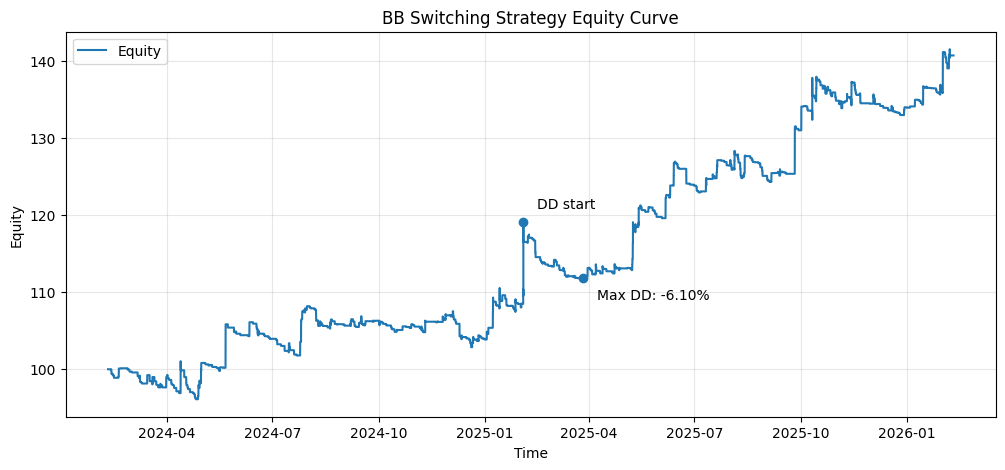

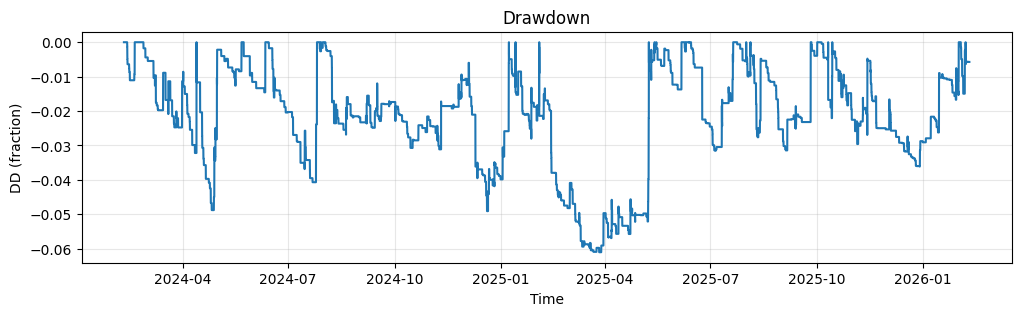

{'final_equity': 140.7137146302667, 'max_drawdown_frac': -0.061043504186701014, 'max_drawdown_pct': -6.104350418670101, 'max_dd_start': Timestamp('2025-02-03 02:07:00+0000', tz='UTC'), 'max_dd_end': Timestamp('2025-03-26 19:47:00+0000', tz='UTC')}


In [41]:
def equity_stats_and_plot(equity: pd.Series, title: str = "Equity Curve"):
    """
    equity: pd.Series indexed by datetime, values are account equity.
    Returns a dict with max drawdown info and plots equity + drawdown.
    """
    equity = equity.dropna().astype(float)
    if equity.empty:
        raise ValueError("Equity series is empty.")

    # Drawdown series
    peak = equity.cummax()
    dd = equity / peak - 1.0  # negative numbers = drawdown
    max_dd = float(dd.min())  # most negative
    dd_end = dd.idxmin()
    dd_start = equity.loc[:dd_end].idxmax()  # peak time before dd_end

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(equity.index, equity.values, label="Equity")
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Equity")
    ax.grid(True, alpha=0.3)

    # Mark max DD start/end
    ax.scatter([dd_start, dd_end], [equity.loc[dd_start], equity.loc[dd_end]], zorder=3)
    ax.annotate("DD start", (dd_start, equity.loc[dd_start]), xytext=(10, 10),
                textcoords="offset points")
    ax.annotate(f"Max DD: {max_dd*100:.2f}%", (dd_end, equity.loc[dd_end]), xytext=(10, -15),
                textcoords="offset points")
    ax.legend()
    plt.show()

    # Optional: plot drawdown separately
    fig, ax2 = plt.subplots(figsize=(12, 3))
    ax2.plot(dd.index, dd.values)
    ax2.set_title("Drawdown")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("DD (fraction)")
    ax2.grid(True, alpha=0.3)
    plt.show()

    return {
        "final_equity": float(equity.iloc[-1]),
        "max_drawdown_frac": max_dd,
        "max_drawdown_pct": max_dd * 100.0,
        "max_dd_start": dd_start,
        "max_dd_end": dd_end,
    }

stats = equity_stats_and_plot(equity, title="BB Switching Strategy Equity Curve")
print(stats)